<a href="https://colab.research.google.com/github/alicienty/HW2/blob/main/Lukyanchikova_classification_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ДОМАШНЕЕ ЗАДАНИЕ

### **Задача:** повторите туториал на датасете **Iris**

**Датасет Iris:**
- 150 примеров цветков ириса
- 3 вида (Setosa, Versicolor, Virginica)
- 4 признака (длина/ширина чашелистика и лепестка)

### **Требования:**
1. **часть 1-2: анализ данных**
   - загрузите датасет `sklearn.datasets.load_iris()`
   - создайте 2 графика распределения классов
   - визуализируйте данные в 2D (выберите 2 любых признака)

2. **часть 3-5: подготовка и обучение**
   - разделите данные 70/30 с `stratify`
   - масштабируйте признаки
   - обучите SVM с линейным ядром

3. **часть 6: эксперименты**
   - попробуйте 3 разных значения C: 0.1, 1, 10
   - сравните accuracy каждой модели
   - выберите лучшую

4. **часть 7-8: оценка**
   - постройте матрицу ошибок для лучшей модели
   - вычислите precision, recall, F1-score
   - найдите и проанализируйте 2 примера ошибок

5. **часть 9: анализ**
   - постройте кривую обучения
   - ответьте: модель переобучается или недообучается?
   - что можно улучшить?

### **Формат сдачи:**
- **Colab ноутбук** с выполненным кодом
- **краткий отчет** (3-5 предложений) с выводами:
  - какая точность достигнута?
  - на каких классах чаще ошибается модель?
  - какие параметры SVM сработали лучше всего?

### **Критерии оценки:**
1. корректная загрузка и анализ данных
2. правильное разделение и масштабирование
3. обучение SVM с разными параметрами (показать, что вы делали как минимум 2 прогона с разными гиперпараметрами, 1 прогон даёт 1 балл)
4. визуализация матрицы ошибок
5. вычисление метрик precision, recall, F1
6. построение кривой обучения
7. представлены ответы на все вопросы из списка требований

### **Дедлайн:** 14 февраля, 23:59 в свои учебные репозитории

In [1]:
# установка необходимых библиотек
!pip install numpy pandas matplotlib seaborn scikit-learn

# импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve

часть 1-2: анализ данных

загрузите датасет sklearn.datasets.load_iris()
создайте 2 графика распределения классов
визуализируйте данные в 2D (выберите 2 любых признака)


In [2]:
# загружаем датасет
iris = datasets.load_iris() # измерения цветков ириса
X = iris.data  # признаки (4 показателя: длина и ширина чашелистик, длина и ширина лепестка)
y = iris.target  # классы (0, 1, 2 - тип ириса)
feature_names = iris.feature_names
target_names = iris.target_names

print(f"размер данных: {X.shape}")
print(f"количество классов: {len(np.unique(y))}")
print(f"названия классов: {target_names}")
print(f"признаки: {feature_names}")

размер данных: (150, 4)
количество классов: 3
названия классов: ['setosa' 'versicolor' 'virginica']
признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
# создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['iris_type'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

In [4]:
# первые 5 строк
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,iris_type
0,5.1,3.5,1.4,0.2,0,class_0
1,4.9,3.0,1.4,0.2,0,class_0
2,4.7,3.2,1.3,0.2,0,class_0
3,4.6,3.1,1.5,0.2,0,class_0
4,5.0,3.6,1.4,0.2,0,class_0


In [5]:
# базовая статистика
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
print(f"Пропуски в данных:\n{df.isnull().sum()}")
# --> в данных нет пропусков

Пропуски в данных:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
iris_type            0
dtype: int64


In [7]:
df['iris_type'].value_counts(normalize=True) # проверяем сбалансированность данных --> данные сбалансированы

,proportion
iris_type,
class_0,0.333333
class_1,0.333333
class_2,0.333333


/tmp/ipython-input-2843771555.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='iris_type', data=df, palette='Set2')


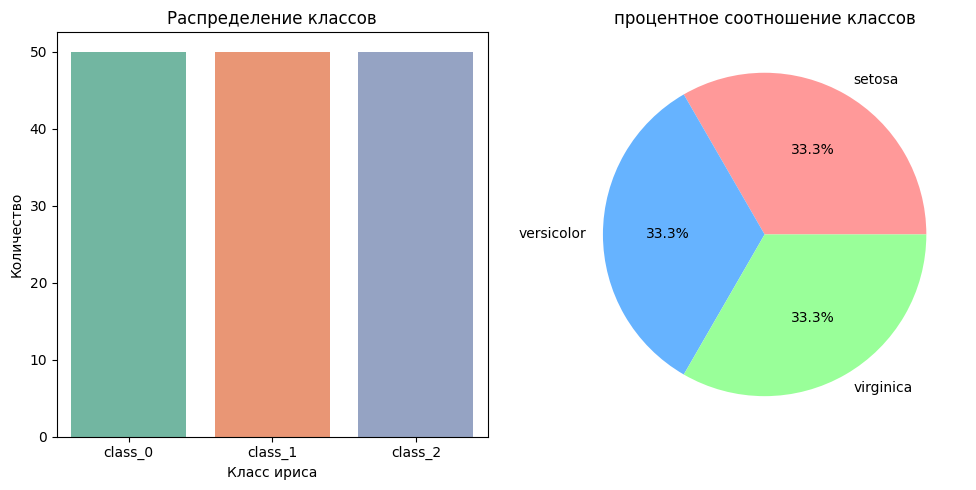

In [8]:
plt.figure(figsize=(10, 5))

# гистограмма по классам
plt.subplot(1, 2, 1)
sns.countplot(x='iris_type', data=df, palette='Set2')
plt.title('Распределение классов')
plt.xlabel('Класс ириса')
plt.ylabel('Количество')

# круговая диаграмма
plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('процентное соотношение классов')

plt.tight_layout()
plt.show()

In [9]:
corr_matrix = df[feature_names].corr()
corr_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


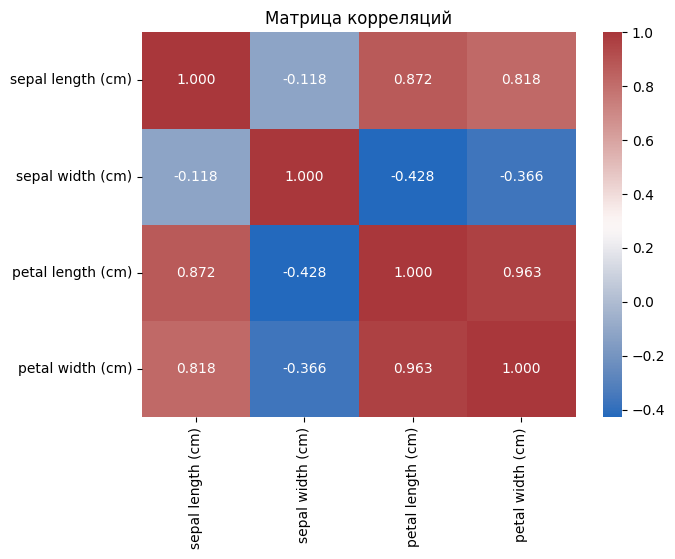

In [10]:
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",
)

plt.title("Матрица корреляций")
plt.show()

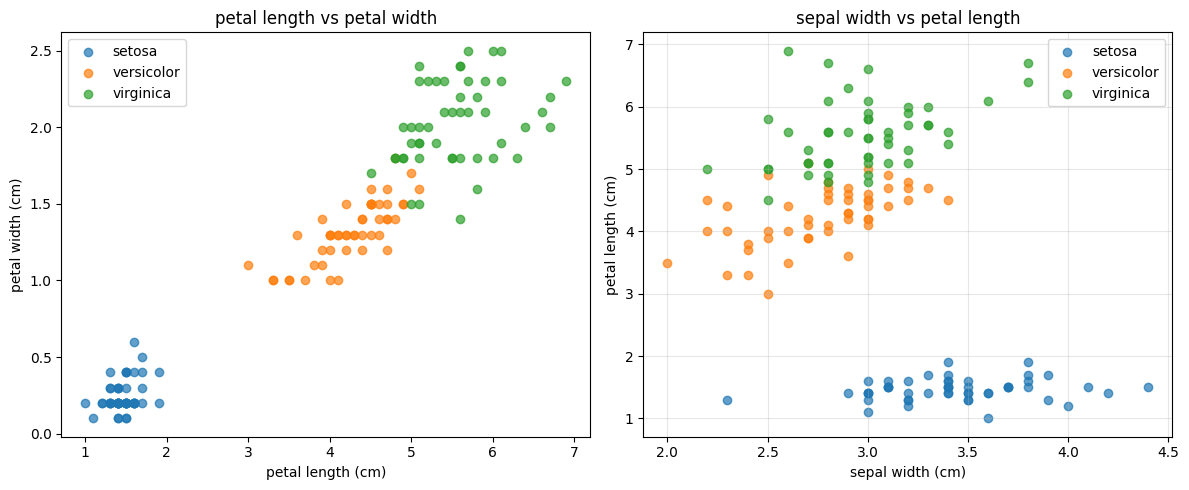

In [11]:
# берем два самых информативных признака (рассматриваем один признак с наибольшей корреляцией и один с наибольшей отрицательной корреляцией)
plt.figure(figsize=(12, 5))

# petal length vs petal width
plt.subplot(1, 2, 1)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['petal length (cm)'],
                df[df['target'] == i]['petal width (cm)'],
                label=iris_class, alpha=0.7)
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.title('petal length vs petal width')

# sepal_width vs petal_length
plt.subplot(1, 2, 2)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['sepal width (cm)'],
                df[df['target'] == i]['petal length (cm)'],
                label=iris_class, alpha=0.7)
plt.xlabel('sepal width (cm)')
plt.ylabel('petal length (cm)')
plt.legend()
plt.title('sepal width vs petal length')
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()


Комментарий по датасету в результате анализа:
- 150 объектов
- 4 числовых признака
- 3 класса, данные сбалансированы
- предстоит решить многоклассовую классификацию
- пропущенные значения отсутствуют
- классы частично разделимы, но потребуется многомерная граница (два класса частично перекрываются)

часть 3-5: подготовка и обучение

разделите данные 70/30 с stratify
масштабируйте признаки
обучите SVM с линейным ядром

In [12]:
# разделяем данные (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {X_train.shape}")
print(f"test size: {X_test.shape}")
print(f"train class distribution: {np.bincount(y_train)}")
print(f"test class distribution: {np.bincount(y_test)}")

train size: (120, 4)
test size: (30, 4)
train class distribution: [40 40 40]
test class distribution: [10 10 10]


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # только transform, не fit!

print("пример до масштабирования (первые 3 признака):")
print(X_train[0, :3])
print("\nпример после масштабирования (первые 3 признака):")
print(X_train_scaled[0, :3])

пример до масштабирования (первые 3 признака):
[4.4 2.9 1.4]

пример после масштабирования (первые 3 признака):
[-1.72156775 -0.33210111 -1.34572231]


In [14]:
# создаем и обучаем модель
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# предсказания
y_pred_linear = svm_linear.predict(X_test_scaled)

# оценка
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"линейный SVM accuracy: {accuracy_linear:.2%}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_linear, target_names=target_names))


линейный SVM accuracy: 100.00%

classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



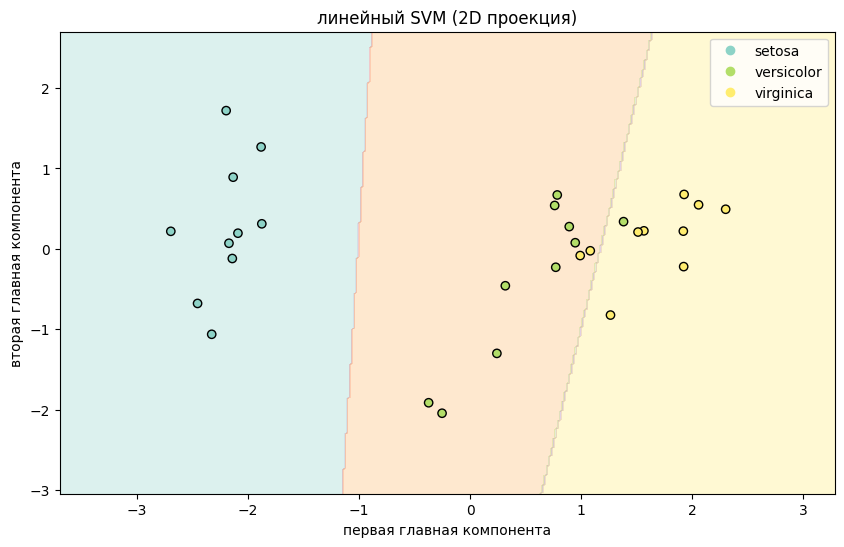

In [15]:
# используем PCA для уменьшения до 2D для визуализации
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# создаем сетку для границы
def plot_decision_boundary_2d(model, X, y, title):
    h = .02  # шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # предсказание для каждой точки сетки
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set3')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Set3')
    plt.xlabel('первая главная компонента')
    plt.ylabel('вторая главная компонента')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
    plt.show()

plot_decision_boundary_2d(svm_linear, X_test_pca, y_test, "линейный SVM (2D проекция)")


часть 6: эксперименты

попробуйте 3 разных значения C: 0.1, 1, 10
сравните accuracy каждой модели
выберите лучшую

C=0.1: accuracy = 90.00%
C=1: accuracy = 96.67%
C=10: accuracy = 96.67%


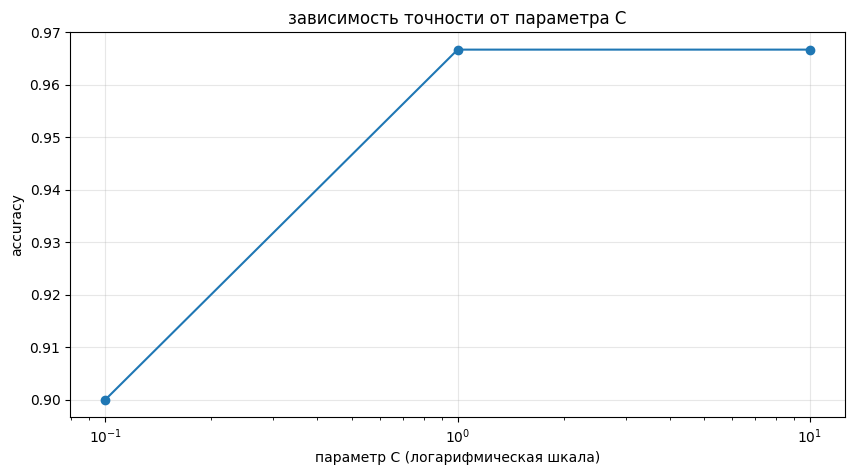

In [17]:
# пробуем разные значения C
C_values = [0.1, 1, 10]
accuracies = []

for C in C_values:
    svm_temp = SVC(kernel='rbf', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)
    print(f"C={C}: accuracy = {acc:.2%}")

# график зависимости accuracy от C
plt.figure(figsize=(10, 5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('параметр C (логарифмическая шкала)')
plt.ylabel('accuracy')
plt.title('зависимость точности от параметра C')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# пробуем обучать при С=0.1
best_svm = SVC(kernel='linear', C=0.1, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 93.33%


In [32]:
# при С=1
best_svm = SVC(kernel='linear', C=1, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 100.00%


In [43]:
# при С=10
best_svm = SVC(kernel='linear', C=10, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 96.67%


In [56]:
# выбираем лучшую модель
best_index = accuracies.index(max(accuracies))
best_C = C_values[best_index]

best_svm = SVC(kernel='linear', C=best_C, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Лучшая модель: C={best_C}, accuracy = {accuracy_best:.2%}")

Лучшая модель: C=1, accuracy = 100.00%


часть 7-8: оценка

постройте матрицу ошибок для лучшей модели
вычислите precision, recall, F1-score
найдите и проанализируйте 2 примера ошибок

In [57]:
# вычисляем матрицу ошибок при С = 1
cm = confusion_matrix(y_test, y_pred_best)
cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

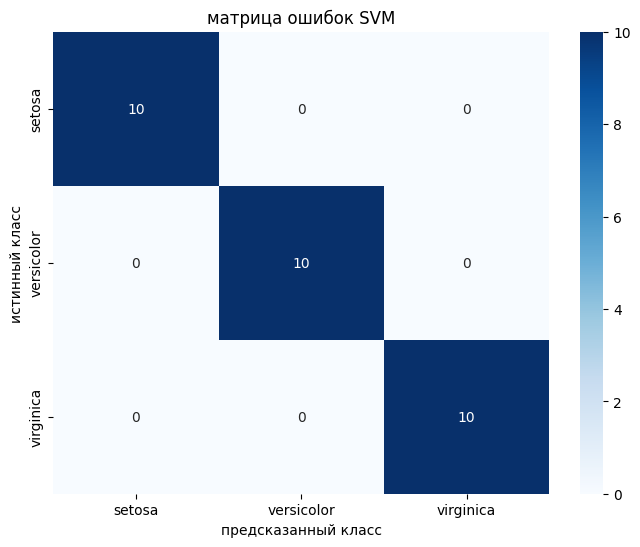

In [58]:
# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [59]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nпримеры ошибок:")

    for i, idx in enumerate(error_indices[:2]):
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: {best_svm.decision_function(X_test_scaled[idx:idx+1])}")
else:
    print("Ошибок нет, все объекты классифицированы корректно.")

количество ошибок: 0
Ошибок нет, все объекты классифицированы корректно.


In [60]:
print(f"количество support vectors: {len(best_svm.support_vectors_)}")
print(f"количество support vectors по классам: {best_svm.n_support_}")
print(f"процент точек, являющихся support vectors: {len(best_svm.support_vectors_)/len(X_train):.1%}")

количество support vectors: 23
количество support vectors по классам: [ 2 11 10]
процент точек, являющихся support vectors: 19.2%


In [61]:
print("детальный отчет по классификации:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

детальный отчет по классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [62]:
# вычисляем метрики
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"итоговые метрики:")
print(f"precision: {precision:.2%}  # точность")
print(f"recall:    {recall:.2%}    # полнота")
print(f"F1-score:  {f1:.2%}     # баланс precision и recall")

итоговые метрики:
precision: 100.00%  # точность
recall:    100.00%    # полнота
F1-score:  100.00%     # баланс precision и recall


p.s. стало интересно, какие ошибки могут возникнуть, поэтому попробуем и на других значениях С тоже

In [52]:
# пробуем обучать при С=0.1
best_svm = SVC(kernel='linear', C=0.1, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 93.33%


In [53]:
# вычисляем матрицу ошибок при С = 0.1
cm = confusion_matrix(y_test, y_pred_best)
cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

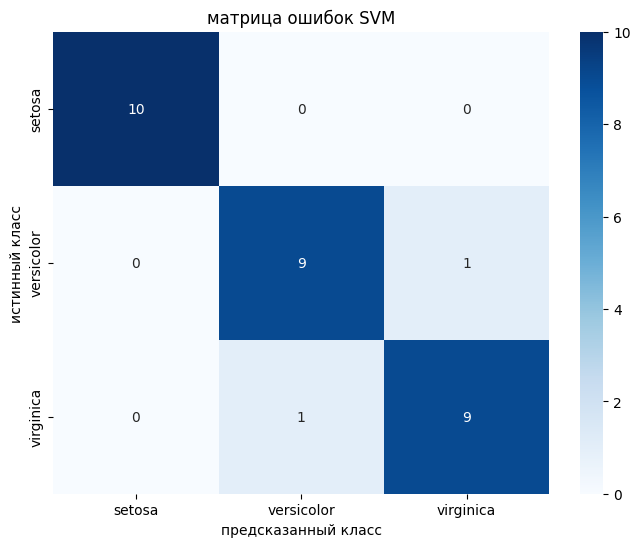

In [54]:
# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [55]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nпримеры ошибок:")

    for i, idx in enumerate(error_indices[:2]):
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: {best_svm.decision_function(X_test_scaled[idx:idx+1])}")
else:
    print("Ошибок нет, все объекты классифицированы корректно.")

количество ошибок: 2

примеры ошибок:

ошибка 1:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.25261913  2.22588297  1.16893454]]

ошибка 2:
  истинный класс: versicolor
  предсказанный:  virginica
  вероятности классов: [[-0.25224672  1.21775999  2.18363223]]


часть 9: анализ

постройте кривую обучения
ответьте: модель переобучается или недообучается?
что можно улучшить?

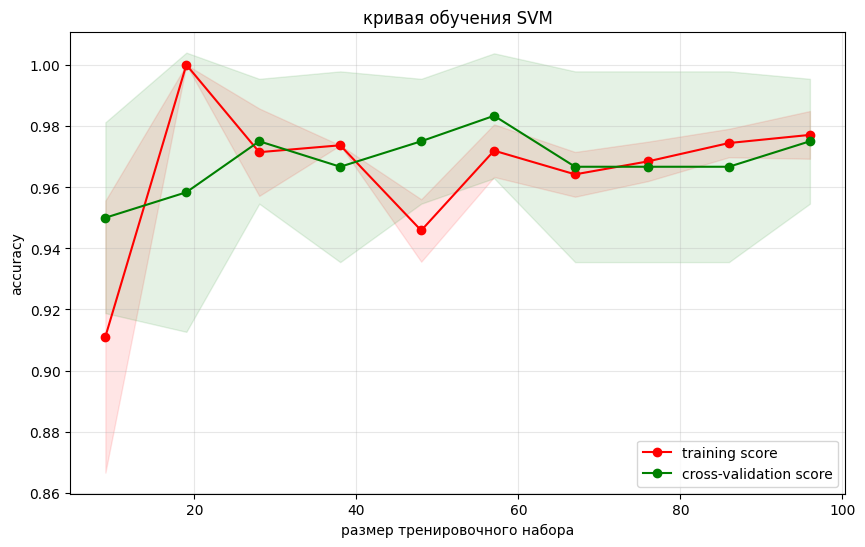

In [42]:
# вычисляем learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# средние значения
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# график
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('размер тренировочного набора')
plt.ylabel('accuracy')
plt.title('кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Комментарий:

Нельзя сказать, что модель переобучается или недообучается, но скорее переобучается, поскольку красная кривая training score чаще несколько превосходит cross-valisation score. Однако данные чистые, хорошо классифицируются, разница в значениях кривых невелика. Можно попробовать добавить больше данных для улучшения, однако на данном датасете это не требуется.

### Краткий отчет


Линейный SVM с подобранным параметром C показал точность 100%.

Модель не допускает ошибок для класса setosa, а типичные ошибки, если они и возникают (на других параметрах С, например), связаны с versicolor и virginica, поскольку их признаки перекрываются, что видно на визуализации sepal width vs petal length. Лучший результат достигнут при C = 1, при этом значении модель не ошибается.